# Recognizing UVA landmarks with neural nets (75 pts)
### Alanna Hazlett
### uwa6xv
### March 2nd, 2025
![UVA Grounds](https://sworld.co.uk/img/img/131/photoAlbum/5284/originals/0.jpg)



The UVA Grounds is known for its Jeffersonian architecture and place in U.S. history as a model for college and university campuses throughout the country. Throughout its history, the University of Virginia has won praises for its unique Jeffersonian architecture.

In this assignment, you will attempt the build an image recognition system to classify different buildlings/landmarks on Grounds. You will earn 75 points for this assignment plus 10 bonus points if (1) your classifier performs exceed 94% accuracy.

To make it easier for you, some codes have been provided to help you process the data, you may modify it to fit your needs. You must submit the .ipynb file via UVA Collab with the following format: yourcomputingID_assignment_2.ipynb

Best of luck, and have fun!

# Load Packages

In [1]:
#!pip install keras-tuner

In [1]:
import sys
import sklearn
import os
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from functools import partial
import PIL
import PIL.Image
import random

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras import regularizers
import keras_tuner as kt

from sklearn.datasets import load_files
from keras.preprocessing import image
from tqdm import tqdm # progress bar


np.random.seed(42) # note that you must use the same seed to ensure consistency in your training/validation/testing
tf.random.set_seed(42)
random.seed(42)

2025-02-28 21:39:29.464504: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-02-28 21:39:29.721258: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-02-28 21:39:29.784284: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1471] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-28 21:39:30.316562: I tensorflow/core/platform/cpu_feature_guard.cc:211] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX, in other operations, rebuild TensorFlow with the appropriate compiler flags.


# Import Dataset
The full dataset is huge (+37GB) with +13K images of 18 classes. So it will take a while to download, extract, and process. To save you time and effort, a subset of the data has been resized and compressed to only 379Mb and stored in my Firebase server. This dataset will be the one you will benchmark for your grade. If you are up for a challenge (and perhaps bonus points), contact the instructor for the full dataset!

In [3]:
# Download dataset from FirebaseStorage
#!wget https://firebasestorage.googleapis.com/v0/b/uva-landmark-images.appspot.com/o/dataset.zip?alt=media&token=e1403951-30d6-42b8-ba4e-394af1a2ddb7

In [4]:
# Extract content
#!unzip "/content/dataset.zip?alt=media"

In [2]:
# from sklearn.datasets import load_files
# from keras.preprocessing import image
# from tqdm import tqdm # progress bar


data_dir = "dataset/"
batch_size = 32;
# IMPORTANT: Depends on what pre-trained model you choose, you will need to change these dimensions accordingly
img_height = 150;
img_width = 150;

# Training Dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split = 0.2,
    subset = "training",
    seed = 42,
    image_size= (img_height, img_width),
    batch_size = batch_size
)

# Validation Dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split = 0.2,
    subset = "validation",
    seed = 42,
    image_size = (img_height, img_width),
    batch_size = batch_size
)


Found 14286 files belonging to 18 classes.
Using 11429 files for training.


2025-02-28 21:39:38.776224: I tensorflow/core/common_runtime/gpu/gpu_device.cc:2021] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46581 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:01:00.0, compute capability: 8.6
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recogn

Found 14286 files belonging to 18 classes.
Using 2857 files for validation.


2025-02-28 21:39:47.621711: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


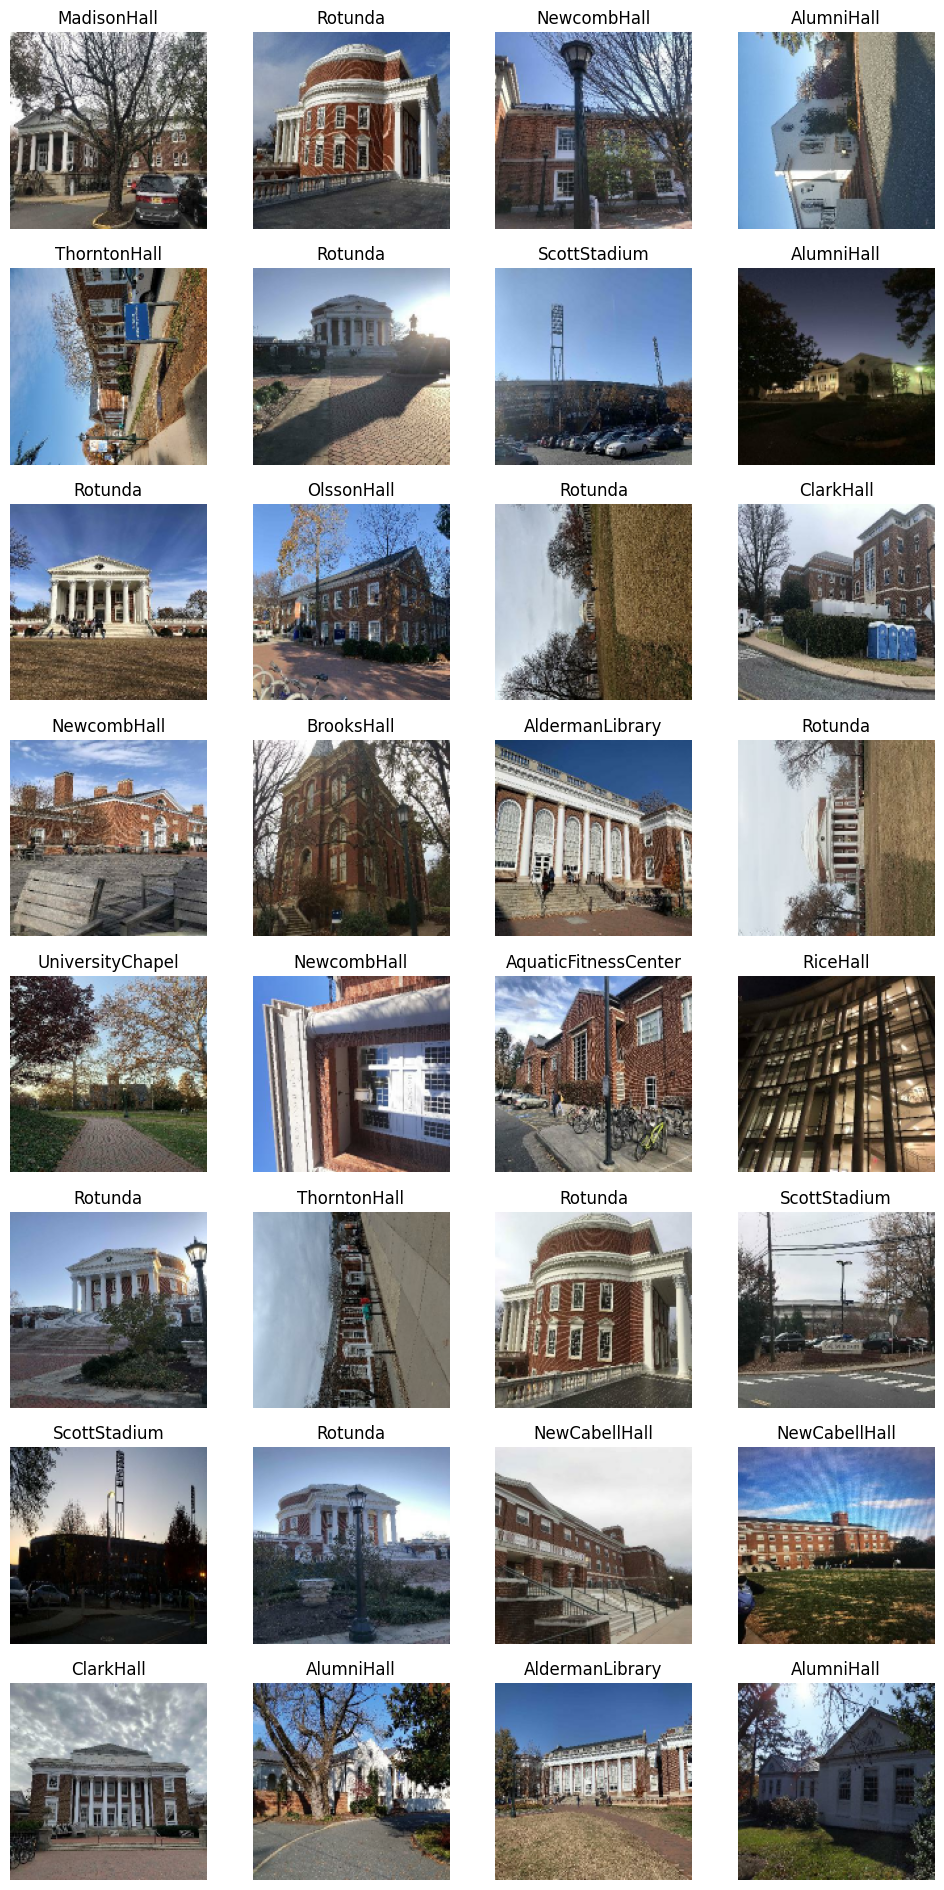

In [3]:
# Visualize some of the train samples of one batch
# Make sure you create the class names that match the order of their appearances in the "files" variable
class_names = ['AcademicalVillage', 'AldermanLibrary', 'AlumniHall', 'AquaticFitnessCenter',
  'BavaroHall', 'BrooksHall', 'ClarkHall', 'MadisonHall', 'MinorHall', 'NewCabellHall',
  'NewcombHall', 'OldCabellHall', 'OlssonHall', 'RiceHall', 'Rotunda', 'ScottStadium',
  'ThorntonHall', 'UniversityChapel']
num_classes = len(class_names)
# Rows and columns are set to fit one training batch (32)
n_rows = 8
n_cols = 4
plt.figure(figsize=(n_cols * 3, n_rows * 3))
for images, labels in train_ds.take(1):
    for i in range (n_rows*n_cols):
        plt.subplot(n_rows, n_cols, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.axis('off')
        plt.title(class_names[labels[i]], fontsize=12)
plt.subplots_adjust(wspace=.2, hspace=.2)


2025-02-28 11:52:54.743743: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


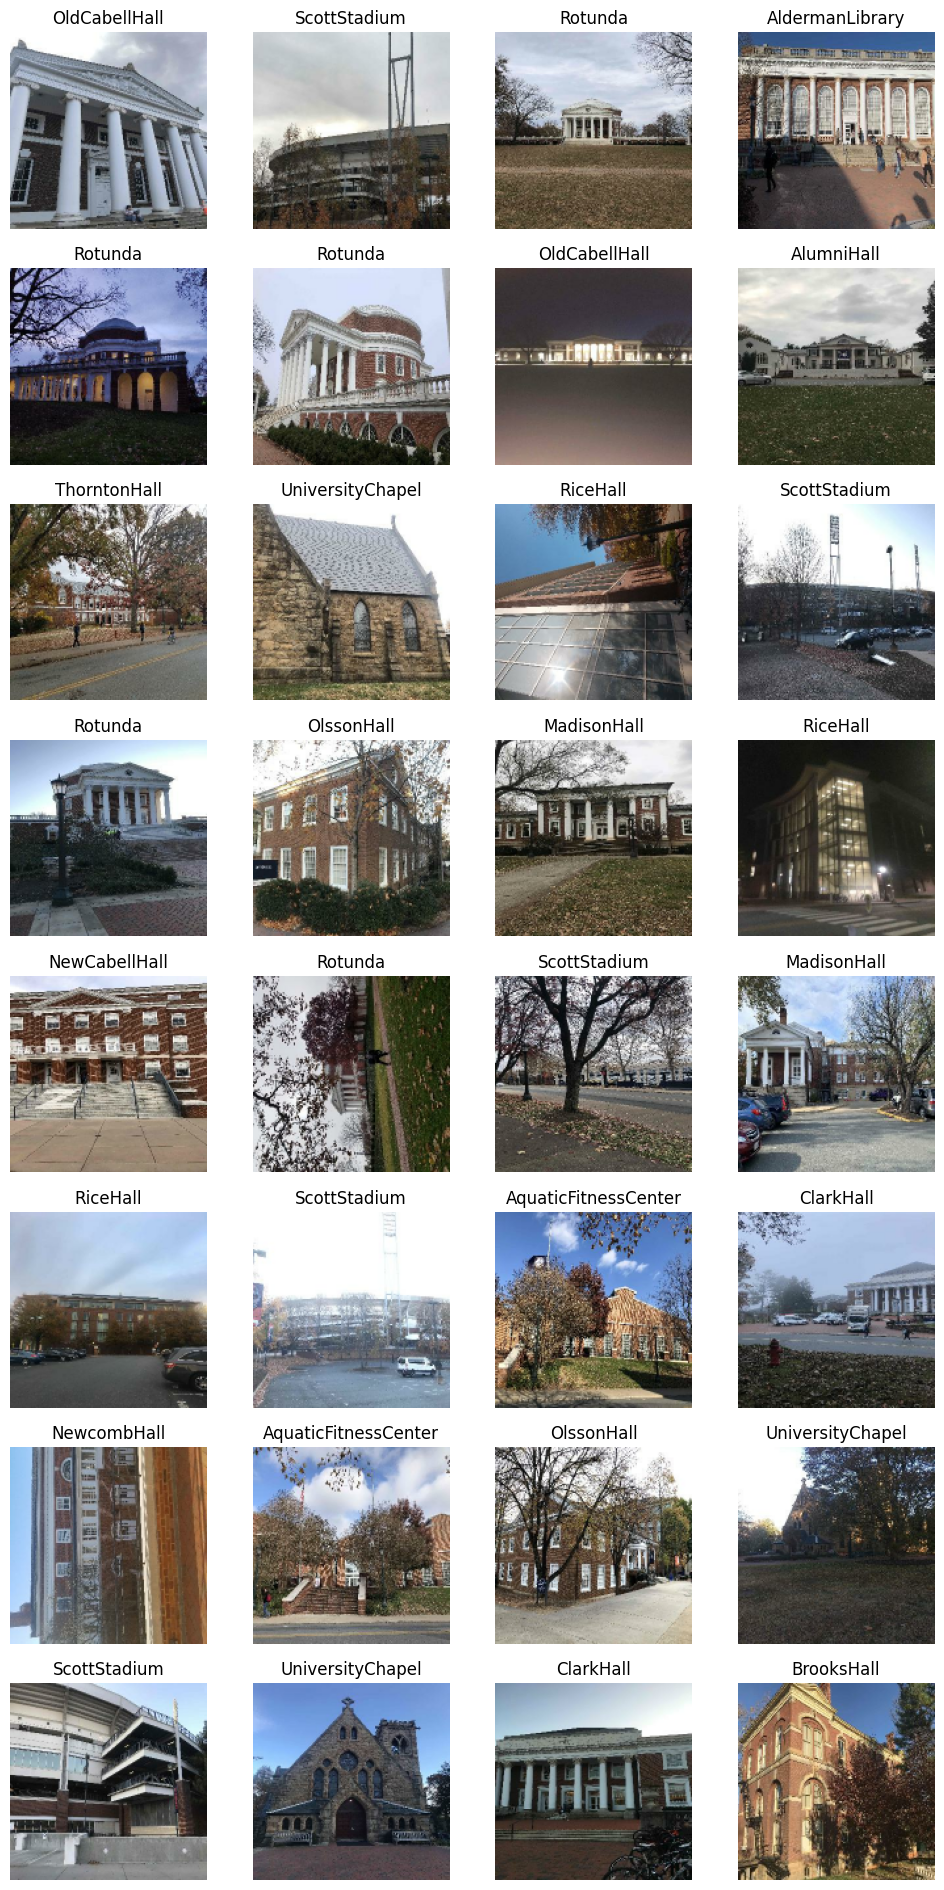

In [4]:
plt.figure(figsize=(n_cols * 3, n_rows * 3))
for images, labels in val_ds.take(1):
    for i in range (n_rows*n_cols):
        plt.subplot(n_rows, n_cols, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.axis('off')
        plt.title(class_names[labels[i]], fontsize=12)
plt.subplots_adjust(wspace=.2, hspace=.2)

    We see in both the training and validation datasets that there is some rotation, with buildings appearing to be on their sides. There is a variety of brightness in the images, with some appearing very dark and some bright. Some images are obstructed by trees, some to the point that you can not seem to see the building in the image. An example of this is Brooks Hall in the validation set. 

# It's your turn: Building a classifier for UVA Landmark Dataset
You may design your own architecture AND re-use any of the exising frameworks.

Best of luck!

## Model 1 - ResNet50

### Build the model

In [7]:
data_augmentation = keras.Sequential(
  [
    layers.RandomFlip("horizontal",
                      input_shape=(img_height,
                                  img_width,
                                  3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
  ]
)

In [8]:
model1 = keras.Sequential()
resnet_model = keras.applications.ResNet50(
               include_top=False,
               weights="imagenet",
               input_tensor=None,
               input_shape=(img_height, img_width, 3),
               pooling="max",
               #classes=num_classes,                       --- Use if you aren't adding additional layers
               #classifier_activation="softmax"
)
# Don't change what ResNet50 has already learned
for layer in resnet_model.layers:
    layer.trainable = False

model1.add(data_augmentation)
model1.add(resnet_model)
model1.add(keras.layers.Dropout(0.2))
model1.add(keras.layers.Flatten())
model1.add(keras.layers.Dense(256, activation='relu'))
model1.add(keras.layers.Dense(352, activation='relu'))
model1.add(keras.layers.Dense(num_classes, activation='softmax'))

In [9]:
# Non-trainable parameters come from pre-trained ResNet50
model1.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential_2 (Sequential)   (None, 150, 150, 3)       0         
                                                                 
 resnet50 (Functional)       (None, 2048)              23587712  
                                                                 
 dropout_1 (Dropout)         (None, 2048)              0         
                                                                 
 flatten_1 (Flatten)         (None, 2048)              0         
                                                                 
 dense_4 (Dense)             (None, 256)               524544    
                                                                 
 dense_5 (Dense)             (None, 352)               90464     
                                                                 
 dense_6 (Dense)             (None, 18)               

### Compile and train the model

In [11]:
optimizer = keras.optimizers.Adam(learning_rate=0.0001)
model1.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [12]:
epochs1 = 40
history1 = model1.fit(train_ds,
                      validation_data=val_ds,
                      epochs=epochs1)

Epoch 1/40


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

358/358 [==============================] - 28s 63ms/step - loss: 2.5674 - accuracy: 0.3207 - val_loss: 1.7901 - val_accuracy: 0.4746
Epoch 2/40
358/358 [==============================] - 22s 60ms/step - loss: 1.6758 - accuracy: 0.5103 - val_loss: 1.4231 - val_accuracy: 0.5772
Epoch 3/40
358/358 [==============================] - 22s 61ms/step - loss: 1.4112 - accuracy: 0.5859 - val_loss: 1.1853 - val_accuracy: 0.6570
Epoch 4/40
358/358 [==============================] - 22s 62ms/step - loss: 1.2357 - accuracy: 0.6363 - val_loss: 1.0859 - val_accuracy: 0.6815
Epoch 5/40
358/358 [==============================] - 23s 62ms/step - loss: 1.1257 - accuracy: 0.6722 - val_loss: 1.0000 - val_accuracy: 0.7133
Epoch 6/40
358/358 [==============================] - 23s 62ms/step - loss: 1.0366 - accuracy: 0.6983 - val_loss: 0.9832 - val_accuracy: 0.7189
Epoch 7/40
358/358 [==============================] - 22s 61ms/step - loss: 0.9742 - accuracy: 0.7162 - val_loss: 0.8975 - val_accuracy: 0.7441
Epo

### Visualize the model

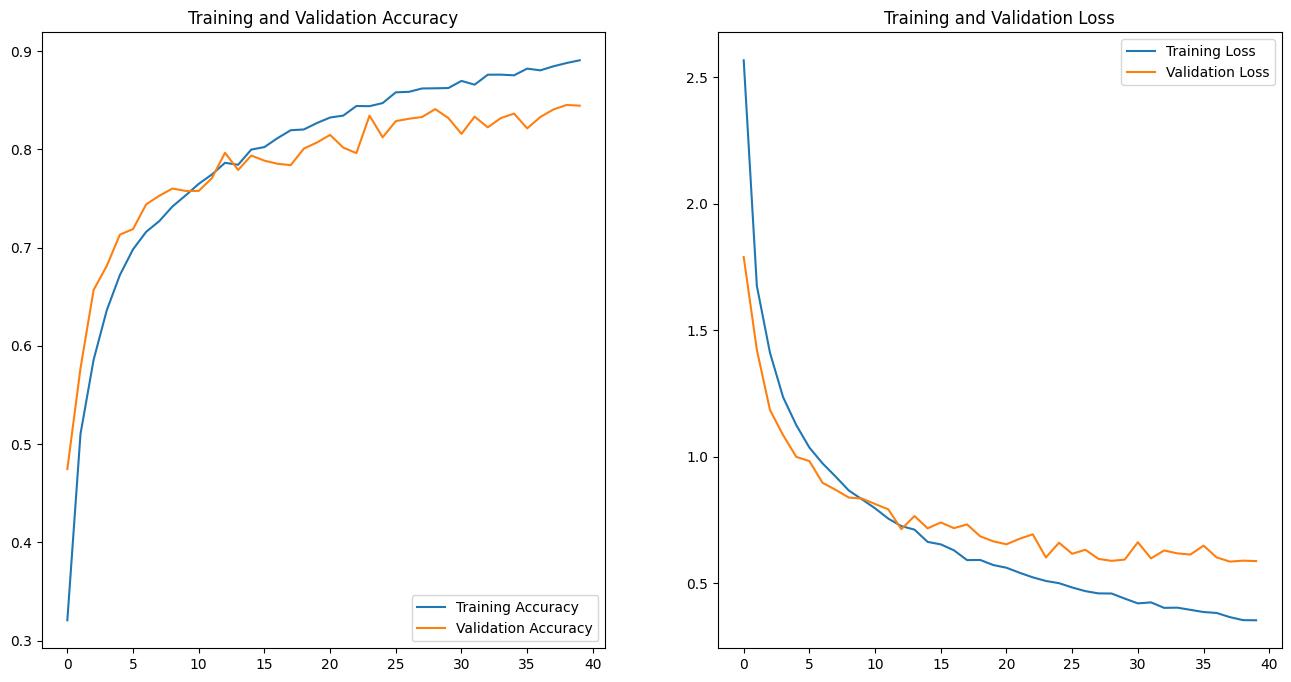

In [13]:
acc1 = history1.history['accuracy']
val_acc1 = history1.history['val_accuracy']

loss1 = history1.history['loss']
val_loss1 = history1.history['val_loss']

epochs_range1 = range(epochs1)

plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range1, acc1, label='Training Accuracy')
plt.plot(epochs_range1, val_acc1, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range1, loss1, label='Training Loss')
plt.plot(epochs_range1, val_loss1, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

### Trying Keras Tuning

In [17]:
import keras

def build_model(hp):
    tuned_model = keras.Sequential()
    resnet_model1 = keras.applications.ResNet50(
               include_top=False,
               weights="imagenet",
               input_tensor=None,
               input_shape=(img_height, img_width, 3),
               pooling="max",
               #classes=num_classes,                       --- Use if you aren't adding additional layers
               #classifier_activation="softmax"
)
    # Don't change what ResNet50 has already learned
    for layer in resnet_model1.layers:
        layer.trainable = False
    
    tuned_model.add(resnet_model1)
    tuned_model.add(keras.layers.Dropout(0.2))
    tuned_model.add(keras.layers.Flatten())
    
    hp_activation = hp.Choice('activation', values =['relu','tanh'])
    hp_layer_1 = hp.Int('layer_1',min_value = 32, max_value = 512, step = 32)
    hp_layer_2 = hp.Int('layer_2',min_value = 32, max_value = 512, step = 32)
    hp_learning_rate = hp.Choice('learning_rate', values = [0.0001, 0.001, 0.01])
    
    #tuned_model.add(keras.layers.Flatten())
    tuned_model.add(keras.layers.Dense(units = hp_layer_1, activation = hp_activation))
    tuned_model.add(keras.layers.Dense(units = hp_layer_2, activation = hp_activation))
    tuned_model.add(keras.layers.Dense(num_classes, activation='softmax'))
    
    tuned_model.compile(optimizer=keras.optimizers.Adam(learning_rate = hp_learning_rate),
                        loss='sparse_categorical_crossentropy',
                        metrics=['accuracy'])
    return tuned_model

build_model(kt.HyperParameters())

<Sequential name=sequential_2, built=False>

In [18]:

tuner = kt.RandomSearch(
    hypermodel=build_model,
    objective="val_accuracy",
    max_trials=10,
    executions_per_trial=2,
    overwrite=True,
    directory="my_dir",
    project_name="helloworld",
)

In [19]:
tuner.search_space_summary()

Search space summary
Default search space size: 4
activation (Choice)
{'default': 'relu', 'conditions': [], 'values': ['relu', 'tanh'], 'ordered': False}
layer_1 (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 512, 'step': 32, 'sampling': 'linear'}
layer_2 (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 512, 'step': 32, 'sampling': 'linear'}
learning_rate (Choice)
{'default': 0.0001, 'conditions': [], 'values': [0.0001, 0.001, 0.01], 'ordered': True}


In [21]:
stop_early = keras.callbacks.EarlyStopping(monitor='val_loss', patience = 3)
tuner.search(train_ds,validation_data= val_ds, epochs = 20, callbacks = [stop_early])

Trial 10 Complete [00h 11m 27s]
val_accuracy: 0.6552327573299408

Best val_accuracy So Far: 0.848617434501648
Total elapsed time: 02h 05m 26s


In [23]:
models = tuner.get_best_models(num_models=2)
best_model = models[0]
best_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:418: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  trackable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 2048)           │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 352)            │        90,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 18)             │         6,354 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,209,074 (92.35 MB)

 Trainable params: 621,362 (2.37 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [41]:
import json
with open('my_dir/helloworld/trial_07/trial.json', 'r') as file:
     data = json.load(file)

In [40]:
data

{'trial_id': '07',
 'hyperparameters': {'space': [{'class_name': 'Choice',
    'config': {'name': 'activation',
     'default': 'relu',
     'conditions': [],
     'values': ['relu', 'tanh'],
     'ordered': False}},
   {'class_name': 'Int',
    'config': {'name': 'layer_1',
     'default': None,
     'conditions': [],
     'min_value': 32,
     'max_value': 512,
     'step': 32,
     'sampling': 'linear'}},
   {'class_name': 'Int',
    'config': {'name': 'layer_2',
     'default': None,
     'conditions': [],
     'min_value': 32,
     'max_value': 512,
     'step': 32,
     'sampling': 'linear'}},
   {'class_name': 'Choice',
    'config': {'name': 'learning_rate',
     'default': 0.0001,
     'conditions': [],
     'values': [0.0001, 0.001, 0.01],
     'ordered': True}}],
  'values': {'activation': 'relu',
   'layer_1': 256,
   'layer_2': 352,
   'learning_rate': 0.0001}},
 'metrics': {'metrics': {'accuracy': {'direction': 'max',
    'observations': [{'value': [0.9415084421634674], '

### Conclusion

I utilized ResNet50 as it is a well known model for image classification and transfer learning. I added data augmentation to reduce overfitting of the model to the training data. This did decrease overfitting, but did not increase the validation accuracy. I tried different number of layers with different number of neurons in each layer. Adding more of either of these increased overfitting. I decided to do some research and work to utilize Keras Tuning to help make informed choices for hyperparameters, such as the number of neurons for a couple of layers, the activation function to use for these, and the learning rate. I utilized the random search, so Keras Tuning will randomly search different combinations of the choices I provided. I ran 10 trials with 2 iterations of 20 epochs. The best result is displayed above, trial 7, which had the activation choice as relu for my two layers, it had the number of neurons for the first dense layer I provided as 256 neurons and then 352 neurons for the second dense layer I provided. It determined that a learning rate of 0.0001 was best with this combination. It had a test accuracy of 0.9415 and a validation accuracy of 0.8486. I applied these directly to my model to see what the results would be and I was still not satisfied with the overfitting, so I decided to add some drop out, I tried 0.2, 0.3, and 0.4. I thought that 0.2 provided the best reduction in overfitting without inhibiting learning. I tried different values for epochs between 10-40 and found that the model was still benefiting from 40 epochs, so I trained the model on that. 

## Model 2 - EfficientNetV2M

### Build the model

In [4]:
model2 = keras.Sequential()
EffNetV2M = keras.applications.EfficientNetV2M(
            include_top=False,
            weights="imagenet",
            input_tensor=None,
            input_shape=(img_height, img_width, 3),
            pooling="max",
            #classes=num_classes,
            #classifier_activation="softmax"
)
# Don't change what EfficientNetV2M has already learned
for layer in EffNetV2M.layers:
    layer.trainable = False

model2.add(EffNetV2M)
model2.add(keras.layers.Dropout(0.3))
model2.add(keras.layers.Flatten())
model2.add(keras.layers.Dense(512, activation='relu'))
model2.add(keras.layers.Dense(256, activation='relu'))
model2.add(keras.layers.Dense(128, activation='relu'))
model2.add(keras.layers.Dense(num_classes, activation='softmax'))

In [5]:
model2.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 efficientnetv2-m (Function  (None, 1280)              53150388  
 al)                                                             
                                                                 
 dropout (Dropout)           (None, 1280)              0         
                                                                 
 flatten (Flatten)           (None, 1280)              0         
                                                                 
 dense (Dense)               (None, 512)               655872    
                                                                 
 dense_1 (Dense)             (None, 256)               131328    
                                                                 
 dense_2 (Dense)             (None, 128)               32896     
                                                        

### Compile and train the model

In [11]:
model2.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [12]:
epochs2 = 40
history2 = model2.fit(train_ds,
                      validation_data=val_ds,
                      epochs=epochs2)

Epoch 1/40


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

  3/358 [..............................] - ETA: 18s - loss: 3.1860 - accuracy: 0.1042    

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


358/358 [==============================] - 63s 104ms/step - loss: 2.0078 - accuracy: 0.4022 - val_loss: 1.5492 - val_accuracy: 0.5467
Epoch 2/40
358/358 [==============================] - 29s 80ms/step - loss: 1.5482 - accuracy: 0.5316 - val_loss: 1.3912 - val_accuracy: 0.5873
Epoch 3/40
358/358 [==============================] - 29s 80ms/step - loss: 1.4025 - accuracy: 0.5840 - val_loss: 1.1930 - val_accuracy: 0.6461
Epoch 4/40
358/358 [==============================] - 29s 80ms/step - loss: 1.3092 - accuracy: 0.6074 - val_loss: 1.1388 - val_accuracy: 0.6692
Epoch 5/40
358/358 [==============================] - 29s 80ms/step - loss: 1.2201 - accuracy: 0.6386 - val_loss: 1.1064 - val_accuracy: 0.6741
Epoch 6/40
358/358 [==============================] - 29s 80ms/step - loss: 1.1522 - accuracy: 0.6534 - val_loss: 1.0009 - val_accuracy: 0.7060
Epoch 7/40
358/358 [==============================] - 29s 79ms/step - loss: 1.1014 - accuracy: 0.6672 - val_loss: 1.0212 - val_accuracy: 0.6986
Ep

### Visualize the model

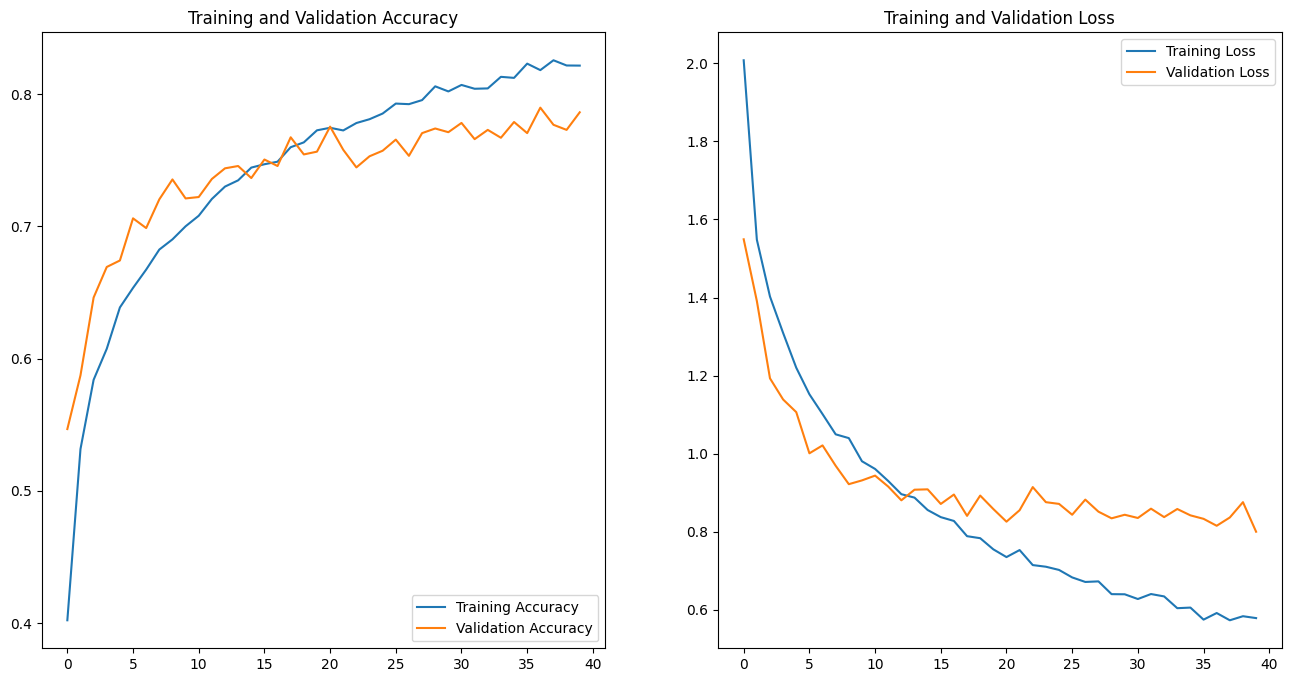

In [13]:
acc2 = history2.history['accuracy']
val_acc2 = history2.history['val_accuracy']

loss2 = history2.history['loss']
val_loss2 = history2.history['val_loss']

epochs_range2 = range(epochs2)

plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range2, acc2, label='Training Accuracy')
plt.plot(epochs_range2, val_acc2, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range2, loss2, label='Training Loss')
plt.plot(epochs_range2, val_loss2, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

### Conclusion

I utilized EfficientNet, another well known established model, with V2M version, because it had one of the highest top-5 accuracy of the EfficientNet variations in Keras Applications. I tried different number of dense layers and with different number of neurons in each dense layer. I found that this model seemed to require one more layer to produce favorable results. I decreased the number of neurons successively for each dense layer from the 1028 that result from EfficientNetV2L towards the number of classes we have, 18. I found that the model needed some reduction in overfitting, so I utilized a drop out rate of 0.3. I tried epochs between 10-40 and found that the model was still benefiting from the large number of epochs, so I stuck with 40 epochs for training. Due to the long run time of the Keras Tuning, I did not get the opportunity to try to utilize that for this model.  

## Model 3 - VGG16

### Build the model

In [10]:
model3 = keras.Sequential()
VGG16 = keras.applications.VGG16(
    include_top=False,
    weights="imagenet",
    input_tensor=None,
    input_shape=(img_height, img_width, 3),
    pooling="max"#,
    #classes=num_classes,
    #classifier_activation="softmax",

)
# Don't change what VGG16 has already learned
for layer in VGG16.layers:
    layer.trainable = False

model3.add(VGG16)
model3.add(keras.layers.Dropout(0.3))
model3.add(keras.layers.Flatten())
model3.add(keras.layers.Dense(512, activation='relu'))
model3.add(keras.layers.Dense(num_classes, activation='softmax'))

In [11]:
model3.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 512)               14714688  
                                                                 
 dropout_2 (Dropout)         (None, 512)               0         
                                                                 
 flatten_2 (Flatten)         (None, 512)               0         
                                                                 
 dense_7 (Dense)             (None, 512)               262656    
                                                                 
 dense_8 (Dense)             (None, 18)                9234      
                                                                 
Total params: 14986578 (57.17 MB)
Trainable params: 271890 (1.04 MB)
Non-trainable params: 14714688 (56.13 MB)
_________________________________________________________________


### Compile and train the model

In [34]:
model3.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [35]:
epochs3 = 40
history3 = model3.fit(train_ds,
                      validation_data=val_ds,
                      epochs=epochs3)

Epoch 1/40
  1/358 [..............................] - ETA: 11:30 - loss: 43.4376 - accuracy: 0.0938

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


358/358 [==============================] - 41s 108ms/step - loss: 8.0433 - accuracy: 0.4272 - val_loss: 1.7405 - val_accuracy: 0.4967
Epoch 2/40
358/358 [==============================] - 19s 53ms/step - loss: 1.9067 - accuracy: 0.5116 - val_loss: 1.5062 - val_accuracy: 0.5796
Epoch 3/40
358/358 [==============================] - 20s 54ms/step - loss: 1.4604 - accuracy: 0.5982 - val_loss: 1.2757 - val_accuracy: 0.6342
Epoch 4/40
358/358 [==============================] - 19s 53ms/step - loss: 1.2591 - accuracy: 0.6463 - val_loss: 1.1161 - val_accuracy: 0.6955
Epoch 5/40
358/358 [==============================] - 19s 53ms/step - loss: 1.1030 - accuracy: 0.6827 - val_loss: 0.9981 - val_accuracy: 0.7273
Epoch 6/40
358/358 [==============================] - 19s 52ms/step - loss: 0.9846 - accuracy: 0.7155 - val_loss: 0.9465 - val_accuracy: 0.7382
Epoch 7/40
358/358 [==============================] - 19s 52ms/step - loss: 0.9054 - accuracy: 0.7396 - val_loss: 0.8819 - val_accuracy: 0.7613
Ep

### Visualize the model

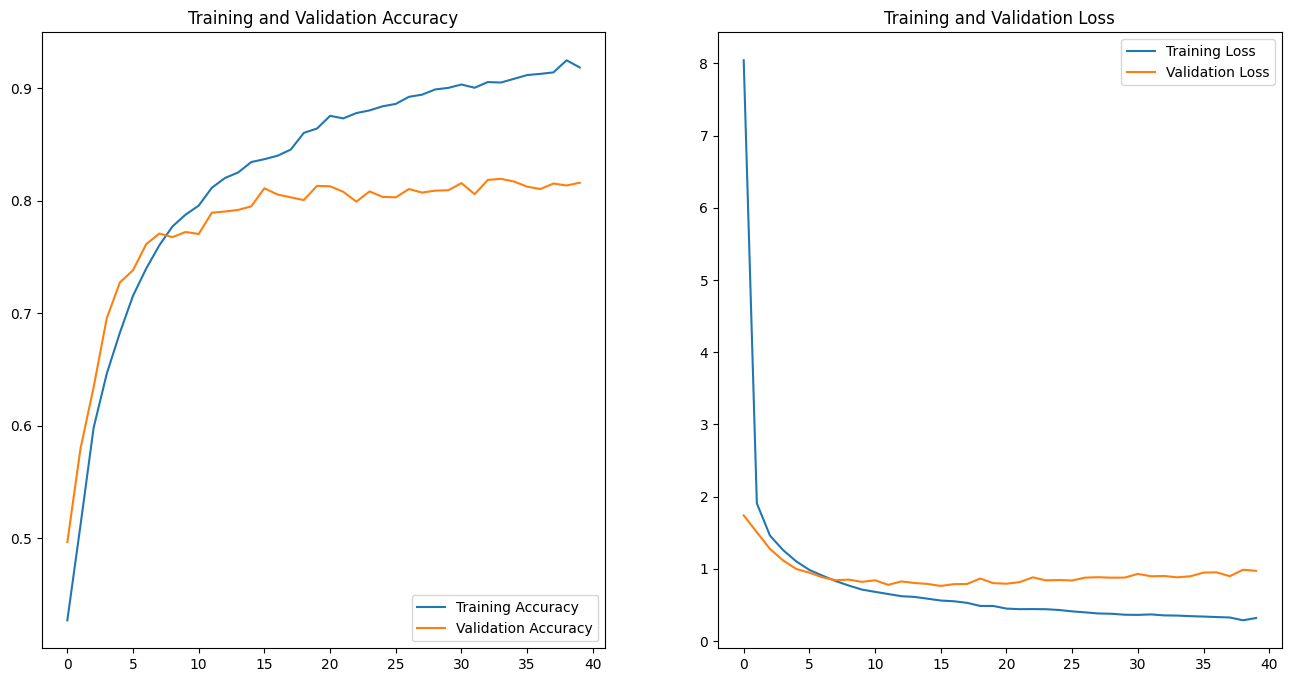

In [38]:
acc3 = history3.history['accuracy']
val_acc3 = history3.history['val_accuracy']

loss3 = history3.history['loss']
val_loss3 = history3.history['val_loss']

epochs_range3 = range(epochs3)

plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range3, acc3, label='Training Accuracy')
plt.plot(epochs_range3, val_acc3, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range3, loss3, label='Training Loss')
plt.plot(epochs_range3, val_loss3, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

### Conclusion

I utilized VGG16, as I learned about it during my literature review for the semester long project. It is a well known model for image classification. I tried different number of dense layers in the model with different number of neurons in the dense layers. I tried different values for epochs between 10-40 and found that the model was still improving at 40, so that is what I trained it on. This model had the most overfitting of them all, so I only added one dense layer and I utilized drop out. I tried different values for drop out between 0.2-0.4. I found that 0.2 was not enough and that 0.4 was too much, so I trained the model on 0.3. We can see in my visualizations that this model is still overfitting, with the training accuracy being higher than the validation accuracy and the training loss lower than the validation loss. Due to the long computation time for Keras Tuning I did not get to try to apply that to this model.